In [21]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from tqdm import tqdm

print(jax.devices())

from src_renyi import (
    ARNN_Z2, RBM_Z2,
    FreeRenyiEnergyObservable,
    free_energy_minimize_SR_SGD,
    free_energy_minimize_scipy,
    renyi_entropy_maximize_SR_SGD,
    renyi2_entropy_and_grad_sampled,
    renyi2_entropy_and_grad_sampled2,
    renyi2_entropy_and_grad_lambda_integral,
    renyi2_entropy_and_grad_cv
)

[CudaDevice(id=0)]


In [65]:
# Hilbert space
from netket.hilbert import Spin
N = 26
N_ancilla = 26
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [66]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

E0404 23:44:03.251288    1419 hlo_lexer.cc:443] Failed to parse int literal: 52718845304270987052


Step    0 | F=-27.549687 | t=7.116s
Step   20 | F=-34.664566 | t=0.585s
Step   40 | F=-35.428175 | t=0.626s
Step   60 | F=-34.284168 | t=0.656s
Step   80 | F=-32.469941 | t=0.704s
Step  100 | F=-37.064569 | t=0.708s
Step  120 | F=-34.658084 | t=0.740s
Step  140 | F=-36.580498 | t=0.773s
Step  160 | F=-38.383186 | t=0.753s
Step  180 | F=-38.150480 | t=0.841s
Step  200 | F=-37.457624 | t=0.774s
Step  220 | F=-39.597528 | t=0.789s
Step  240 | F=-38.084856 | t=0.815s
Step  260 | F=-40.355467 | t=0.858s
Step  280 | F=-40.355804 | t=0.926s


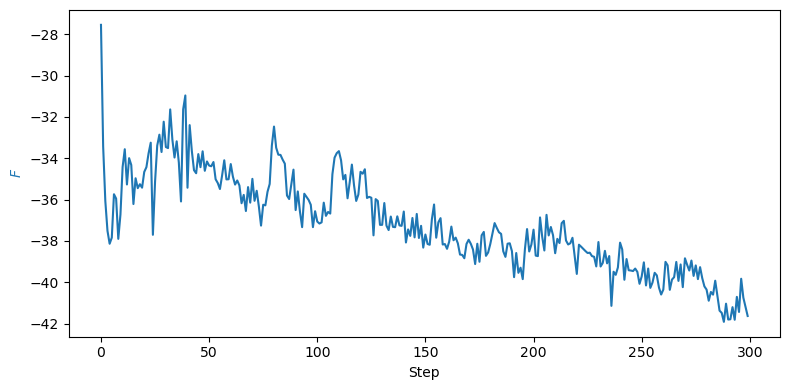

Best solution: S₂=7.252690, E=-27.417005, F=-40.471847


In [67]:
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*1)
T = 1.8

n_steps = 300
lr = optax.linear_schedule(0.05, 0.001, n_steps)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)
_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

In [68]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*4, chunk_size=None)

T_array = np.linspace(0, 4, 41)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None
os.makedirs(f"../data/N{N}/params", exist_ok=True)

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate = optax.linear_schedule(0.05, 0.001, n_steps),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters
    filename = f"../data/N{N}/params/params_T_{T:.3f}.msgpack"

    with open(filename, "wb") as f:
        f.write(serialization.to_bytes(best_params))

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

os.makedirs(f"../data/N{N}", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/N{N}/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Temperaturas:   0%|          | 0/41 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-38.798132
Step   50 | F=-43.468926
Step  100 | F=-43.467988
Step  150 | F=-43.469643
Step  200 | F=-43.469454
Step  250 | F=-43.469656


2026-04-04 23:57:15.849430: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 4.27GiB (4581732709 bytes) by rematerialization; only reduced to 7.12GiB (7642153024 bytes), down from 7.21GiB (7744061536 bytes) originally
2026-04-04 23:57:27.031319: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.15GiB (rounded to 7681804288)requested by op 
2026-04-04 23:57:27.031536: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] *___________________________________________________________________________________________________
E0404 23:57:27.031563    1419 pjrt_stream_executor_client.cc:3077] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 7681804072 bytes. [tf-allocator-allocation-error='']
Temperaturas:   0%|          | 0/41 [09:22<?, ?it/s]


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 7681804072 bytes.

Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()